In [3]:
# manually define project root
PROJECT_ROOT = Path("/Users/shreechatterjee/jak-selectivity-screening")

# set working directory
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/shreechatterjee/jak-selectivity-screening


In [1]:
import os
import csv
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem, DataStructs, rdFingerprintGenerator

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [32]:
!python src/chembl_preprocessing.py

Loading ChEMBL/chembl_jak1.tsv IC50 rows...
  ChEMBL/chembl_jak1.tsv: 14879 IC50 rows kept (0 unit-converted to nM), 32 dropped (invalid SMILES), 0 dropped (unparseable units)
Loading ChEMBL/chembl_jak2.tsv IC50 rows...
  ChEMBL/chembl_jak2.tsv: 19085 IC50 rows kept (1 unit-converted to nM), 32 dropped (invalid SMILES), 0 dropped (unparseable units)
Compounds with IC50 defined in BOTH JAK1 and JAK2: 8099
Qualifying compounds (>=1 matching assay description): 5779

Total compounds with computable selectivity: 5779

Threshold | JAK1-over-JAK2 (n, %) | JAK2-over-JAK1 (n, %)
>= 2x   | 4068 (70.39%) | 487 (8.43%)
>= 5x   | 2808 (48.59%) | 260 (4.50%)
>= 10x   | 1947 (33.69%) | 126 (2.18%)
>= 20x   | 1151 (19.92%) | 57 (0.99%)
>= 30x   | 705 (12.20%) | 39 (0.67%)
>= 50x   | 357 (6.18%) | 21 (0.36%)

Done. Outputs written to /Users/shreechatterjee/jak-selectivity-screening/data/ChEMBL


In [5]:
shared_df = pd.read_csv("data/ChEMBL/ChEMBL Data Preprocessing/ic50_shared_compounds.tsv", sep='\t')
shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."


In [7]:
# fold selectivity: how many-fold more potent the compound is on its stronger target
fold = shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].max(axis=1) / shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].min(axis=1)

SELECTIVITY_THRESHOLD = 5  # fold-change cutoff to call a compound "selective" at all — adjust as needed

shared_df['fold_selectivity'] = fold

# 1. Selective (yes/no)
shared_df['selective'] = np.where(fold >= SELECTIVITY_THRESHOLD, 'Yes', 'No')

# 2. Selective for which protein
shared_df['selective_for'] = np.select(
    [
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] < shared_df['JAK2_IC50_nM']),
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] > shared_df['JAK2_IC50_nM']),
    ],
    ['JAK1', 'JAK2'],
    default='None'
)

# 3. Continuous fold-selectivity is just `fold_selectivity` above

# 4. Selectivity category (binned)
bins   = [0, 2, 5, 10, 20, 30, 50, np.inf]
labels = ['<2x', '2x', '5x', '10x', '20x', '30x', '50x+']
shared_df['selectivity_category'] = pd.cut(fold, bins=bins, labels=labels, right=False)

shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",7.500000,Yes,JAK1,5x
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",3.380952,No,None,2x
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.545455,Yes,JAK1,5x
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.000000,No,None,2x
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.822785,Yes,JAK1,5x
...,...,...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.952381,No,None,2x
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.197802,No,None,2x
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.325581,No,None,2x
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.454545,No,None,2x


In [9]:
jak2_selective_df = shared_df.query("selective_for == 'JAK2' and fold_selectivity >= 5")
jak1_selective_df = shared_df.query("selective_for == 'JAK1' and fold_selectivity >= 5")
non_selective_df = shared_df.query("selective == 'No'")

In [39]:
jak2_selective_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
39,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)c(F)c...,3270.00,501.00000,"Enzymatic Assay: Briefly, specific kinase/subs...",6.526946,Yes,JAK2,5x
40,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)n...,3220.00,570.00000,"Enzymatic Assay: Briefly, specific kinase/subs...",5.649123,Yes,JAK2,5x
41,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)nc3)n...,14000.00,2060.00000,"Enzymatic Assay: Briefly, specific kinase/subs...",6.796117,Yes,JAK2,5x
196,CC(C)(C)OC(=O)N1CC(CC#N)(n2nc(NC3CC3)c3c(=O)[n...,40.80,2.51000,Biochemical HTRF Assay : The ability of compou...,16.254980,Yes,JAK2,10x
381,CC(C)(C)S(=O)(=O)Nc1cc(-n2ccc3cnc(Nc4cc(F)c5c(...,6082.76,49.39640,AlphaLisa Assay: 1. Add 20 μl of the diluted c...,123.141767,Yes,JAK2,50x+
...,...,...,...,...,...,...,...,...
5538,O=C(Nc1ccc2cnccc2c1)[C@@H]1CC1c1ccc(S(=O)(=O)N...,23.00,2.50000,JAK Kinase Assays: Compounds were prepared in ...,9.200000,Yes,JAK2,5x
5539,O=C(Nc1ccc2cnccc2c1)[C@@H]1CC1c1ccc(S(=O)(=O)N...,25.00,1.09545,JAK Kinase Assays: Compounds were prepared in ...,22.821671,Yes,JAK2,20x
5566,O=C(O)C(Cc1ccccc1)Oc1nc(-c2cnn3ccccc23)nc(N[C@...,970.00,74.00000,In Vitro JAK kinase Assays: The catalytic doma...,13.108108,Yes,JAK2,10x
5573,O=C(O)Cn1cc(Nc2ncc3ccn(Cc4ccsc4)c3n2)cn1,550.00,100.00000,JAK/TYK2 Assay: 10 mM test compound stock or 1...,5.500000,Yes,JAK2,5x


In [13]:
jak1_selective_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
13,C#CCCOC(=O)N1CC[C@@H](n2cc(C(N)=O)c(Nc3ccc(F)c...,9.0,154.0,Biochemical HTRF Assay: The ability of compoun...,17.111111,Yes,JAK1,10x
17,C#Cc1ccc(C(=O)c2ccc(-c3nc4cnc5[nH]ccc5c4n3[C@H...,2.0,30.7,Enzymatic Inhibition Assay: 11-point dosing se...,15.350000,Yes,JAK1,10x
18,C#Cc1ccc(C(=O)c2ccc(CCc3nc4cnc5[nH]ccc5c4n3[C@...,1.5,80.9,Enzymatic Inhibition Assay: 11-point dosing se...,53.933333,Yes,JAK1,50x+
19,C#Cc1ccc(C(=O)c2ccc(COCc3nc4cnc5[nH]ccc5c4n3[C...,0.7,19.4,Enzymatic Inhibition Assay: 11-point dosing se...,27.714286,Yes,JAK1,20x
20,C#Cc1ccc(C(=O)c2ccc(OCc3nc4cnc5[nH]ccc5c4n3[C@...,0.8,15.7,Enzymatic Inhibition Assay: 11-point dosing se...,19.625000,Yes,JAK1,10x
...,...,...,...,...,...,...,...,...
5760,c1ccc(CCCN[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)...,16.0,290.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",18.125000,Yes,JAK1,10x
5761,c1ccc(CCNC2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,6.1,190.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",31.147541,Yes,JAK1,30x
5762,c1ccc(CCNC[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)...,5.7,72.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",12.631579,Yes,JAK1,10x
5764,c1ccc(CCN[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)C...,6.3,94.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",14.920635,Yes,JAK1,10x


In [15]:
non_selective_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",7.500000,No,None,5x
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",3.380952,No,None,2x
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.545455,No,None,5x
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.000000,No,None,2x
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.822785,No,None,5x
...,...,...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.952381,No,None,2x
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.197802,No,None,2x
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.325581,No,None,2x
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.454545,No,None,2x


Total compounds combined: 5779
  JAK2-selective: 126
  JAK1-selective: 1950
  Non-selective: 3703
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
Explained variance (first 5 PCs): [0.0158 0.0138 0.0121 0.0117 0.0109]
Cumulative variance (PC1+PC2): 2.95%


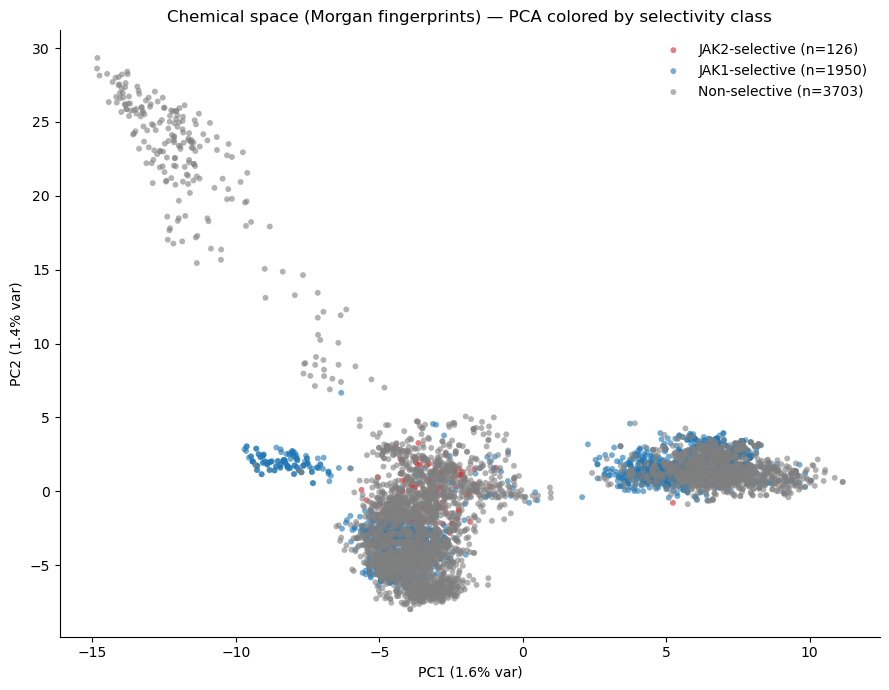


Saved: pca_results_selectivity_morgan.csv, morgan_pca_selectivity.png


In [29]:
"""
Morgan Fingerprint calculation + PCA visualization for JAK selectivity datasets
=================================================================================

Assumes you already have three pandas DataFrames in memory (as in your notebook):
    jak2_selective_df   - compounds selective for JAK2
    jak1_selective_df   - compounds selective for JAK1
    non_selective_df    - non-selective compounds

Each must have a 'smiles' column.

If instead you have these saved as CSVs, edit the LOAD DATA section below to
read them with pd.read_csv(...) instead of assuming they're already defined.

Requirements:
    pip install rdkit pandas numpy scikit-learn matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    tmp = df[["smiles"]].copy()
    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []
for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4 (common default for similarity/ML)
# fpSize=2048 -> standard bit-vector length; bump to 4096 for less bit collision
# on larger/more diverse datasets, at the cost of more memory.
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset (no discriminative value)
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. Standardize + PCA
# ----------------------------------------------------------------------------
# Fingerprint bits are binary, so standardizing is optional (PCA on raw binary
# data is common practice for fingerprints), but scaling still helps balance
# very rare vs. very common bits. Toggle SCALE = False to skip it.
SCALE = True

if SCALE:
    scaler = StandardScaler()
    X_input = scaler.fit_transform(X)
else:
    X_input = X.astype(float)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_input)

explained_var = pca.explained_variance_ratio_
print("Explained variance (first 5 PCs):", np.round(explained_var[:5], 4))
print(f"Cumulative variance (PC1+PC2): {explained_var[:2].sum():.2%}")

pca_df = combined_df.copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot PC1 vs PC2, color-coded by dataset
# ----------------------------------------------------------------------------
colors = {
    "JAK2-selective": "#d62728",  # red
    "JAK1-selective": "#1f77b4",  # blue
    "Non-selective": "#7f7f7f",   # gray
}

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in colors.items():
    subset = pca_df[pca_df["dataset"] == label]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=18,
        alpha=0.6,
        c=color,
        label=f"{label} (n={len(subset)})",
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({explained_var[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({explained_var[1]:.1%} var)")
ax.set_title("Chemical space (Morgan fingerprints) — PCA colored by selectivity class")
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_pca_selectivity.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
pca_df.to_csv("pca_results_selectivity_morgan.csv", index=False)
print("\nSaved: pca_results_selectivity_morgan.csv, morgan_pca_selectivity.png")

# Note on interpretability: unlike Mordred descriptors, individual fingerprint
# bits don't map to named chemical properties, so PC loadings here aren't
# directly interpretable the way they are for Mordred. If you want to know
# *why* clusters separate, it's more useful to pick a few molecules from each
# cluster and visually compare their structures (e.g. with Chem.Draw), or to
# rerun the Mordred-based script and compare the two chemical space pictures.

Total compounds combined: 5779
  JAK2-selective: 126
  JAK1-selective: 1950
  Non-selective: 3703
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


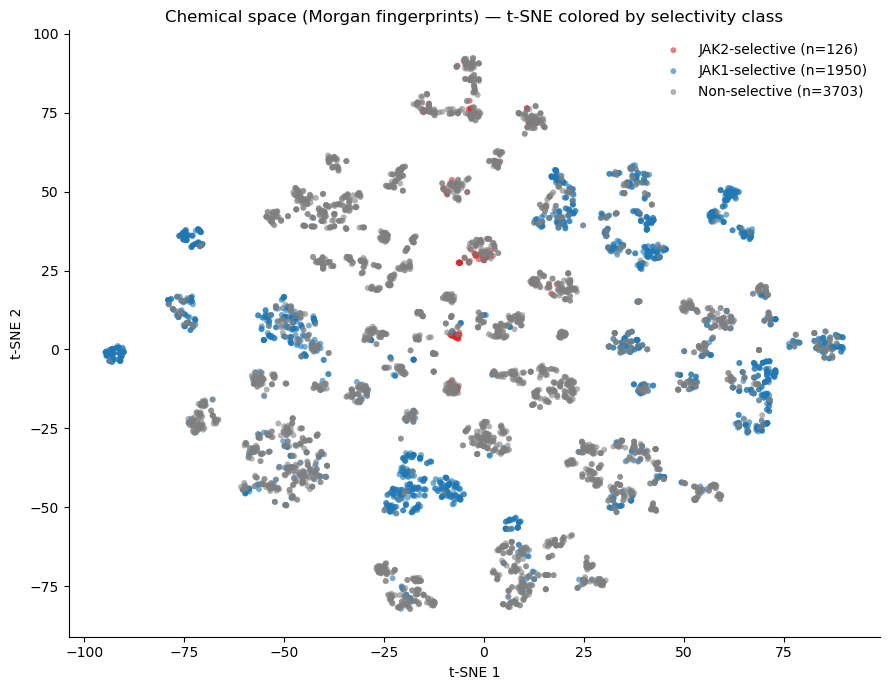


Saved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity.png


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



k-NN purity check (k=10, Jaccard/Tanimoto distance on fingerprints)

Non-selective (n=3703, base rate=64.1%):
  Mean fraction of k=10 nearest neighbors sharing this class: 85.8%
  Enrichment over random expectation: 1.3x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

JAK1-selective (n=1950, base rate=33.7%):
  Mean fraction of k=10 nearest neighbors sharing this class: 78.3%
  Enrichment over random expectation: 2.3x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

JAK2-selective (n=126, base rate=2.2%):
  Mean fraction of k=10 nearest neighbors sharing this class: 46.3%
  Enrichment over random expectation: 21.2x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Saved: knn_purity_results.csv

Interpretation: enrichment > 1x with a low p-value means compounds of that class tend to be structurally closer to each other than random chance would predict -- i.e. there IS real chemical structure associated with that class, even if it's not obviousl

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



Nearest non-selective neighbor check for JAK2-selective compounds
Threshold: selective >= 10.0x, boundary zone = [5.0, 10.0)x, true cliff < 5.0x

pair_type
true activity cliff    66
boundary artifact      60
Name: count, dtype: int64

Closest 10 JAK2-selective / non-selective pairs by structural similarity:
 jak2_fold_selectivity  nearest_nonselective_fold_selectivity  tanimoto_similarity           pair_type
             10.000000                               5.500000             1.000000   boundary artifact
             17.667845                               1.000000             0.911765 true activity cliff
             18.000000                               9.666667             0.885714   boundary artifact
             24.400000                               7.300000             0.885246   boundary artifact
             15.714286                               9.666667             0.876712   boundary artifact
             33.000000                               9.666667           

In [35]:
"""
Morgan Fingerprint calculation + t-SNE visualization for JAK selectivity datasets
=================================================================================

Assumes you already have three pandas DataFrames in memory (as in your notebook):
    jak2_selective_df   - compounds selective for JAK2
    jak1_selective_df   - compounds selective for JAK1
    non_selective_df    - non-selective compounds

Each must have a 'smiles' column.

If instead you have these saved as CSVs, edit the LOAD DATA section below to
read them with pd.read_csv(...) instead of assuming they're already defined.

Requirements:
    pip install rdkit pandas numpy scikit-learn matplotlib

Why t-SNE instead of PCA here: Morgan fingerprints are high-dimensional, sparse,
binary data. Linear PCA struggles to compress that into 2 axes (you'll typically
see each of the first several PCs explaining only ~1-2% of variance individually).
t-SNE is a nonlinear technique that's much better suited to revealing cluster
structure in fingerprint-type data, which is why it (along with UMAP) is the more
common choice for visualizing fingerprint-based chemical space.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    # Keep fold_selectivity alongside smiles -- needed later to distinguish
    # "boundary artifact" overlap from genuine activity-cliff overlap.
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")
    tmp = df[cols].copy()
    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan
    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []
for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4 (common default for similarity/ML)
# fpSize=2048 -> standard bit-vector length; bump to 4096 for less bit collision
# on larger/more diverse datasets, at the cost of more memory.
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset (no discriminative value)
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. (Optional) PCA pre-reduction, then t-SNE
# ----------------------------------------------------------------------------
# Running t-SNE directly on 2000+ binary dimensions works but is slow and can
# be noisy. Standard practice is to first reduce to ~50 dims with PCA (fast,
# linear, keeps the bulk of the signal), then let t-SNE do the nonlinear work
# from there. Set PCA_PREREDUCE = False to skip straight to t-SNE on raw bits.
PCA_PREREDUCE = True
N_PCA_DIMS = 50  # only used if PCA_PREREDUCE is True

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
          f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)")

# perplexity roughly controls the balance between local and global structure;
# scikit-learn recommends keeping it well below the number of samples.
PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    n_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot TSNE1 vs TSNE2, color-coded by dataset
# ----------------------------------------------------------------------------
colors = {
    "JAK2-selective": "#d62728",  # red
    "JAK1-selective": "#1f77b4",  # blue
    "Non-selective": "#7f7f7f",   # gray
}

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in colors.items():
    subset = tsne_df[tsne_df["dataset"] == label]
    ax.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        s=18,
        alpha=0.6,
        c=color,
        label=f"{label} (n={len(subset)})",
        edgecolors="none",
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) — t-SNE colored by selectivity class")
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_tsne_selectivity.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
print("\nSaved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity.png")

# Notes:
# - t-SNE axes have no inherent meaning (unlike PCA loadings) — distances within
#   a cluster and cluster shape aren't meaningful, only relative grouping is.
#   Don't over-interpret exact distances or axis values.
# - t-SNE is stochastic and sensitive to `perplexity` and `random_state`. If the
#   plot looks like one big blob or oddly stringy, try re-running with a
#   different perplexity (roughly: smaller for tighter local clusters, larger
#   for more global structure) before concluding there's no separation.
# - If you want to know *why* clusters separate, it's more useful to pick a few
#   molecules from each cluster and visually compare their structures
#   (e.g. with Chem.Draw), since fingerprint bits aren't individually
#   interpretable the way Mordred descriptors are.

# ----------------------------------------------------------------------------
# 7. k-NN purity check — is there real structural signal despite low n / visual
#    overlap in the 2D embedding?
# ----------------------------------------------------------------------------
# Rationale: a 2D t-SNE/PCA plot compresses away a lot of information, and with
# only ~126 JAK2-selective compounds among 5,779, a real-but-subtle structural
# signal can be invisible to the eye even if it exists. This check works
# directly in fingerprint space (not the 2D embedding) and asks, for each
# compound: "of my k nearest structural neighbors, what fraction share my
# class?" then compares that to the class's overall base rate in the dataset.
# If JAK2-selective compounds are structurally random with respect to class,
# their neighbor purity should hover around the base rate (~2.2%). If there's
# real (even minority-subgroup) structure, purity will sit meaningfully above
# it, with a significance test to back that up.
from sklearn.neighbors import NearestNeighbors

K = 10  # number of nearest neighbors to check; try 5-20

# Use Jaccard/Tanimoto distance on the raw binary fingerprints — this is the
# standard similarity metric for fingerprints (better suited than Euclidean).
nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")  # +1 to exclude self
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self (always the nearest neighbor at distance 0)

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    # observed mean purity: for each compound of this class, fraction of its
    # k neighbors that are also this class
    neighbor_labels = labels[neighbor_idx[cls_idx]]  # shape (n_cls, K)
    observed_purity = (neighbor_labels == cls).mean()

    # permutation test: shuffle class labels many times and recompute the same
    # statistic, to get a null distribution and an empirical p-value
    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        # sample same number of indices as observed for comparability, using
        # the same neighbor structure (fingerprint space is fixed; only labels
        # are permuted, which is the correct null model here)
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
purity_df.to_csv("knn_purity_results.csv")
print("\nSaved: knn_purity_results.csv")
print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict -- i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE/PCA "
    "plot. Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size -- consistent with what "
    "the overlapping t-SNE clusters suggested, but now with a statistic behind it "
    "rather than a visual impression."
)

# ----------------------------------------------------------------------------
# 8. Nearest non-selective neighbor check for JAK2-selective compounds:
#    boundary-labeling artifact vs. genuine activity cliff
# ----------------------------------------------------------------------------
# Rationale: when a JAK2-selective (red) compound sits right next to a
# non-selective (gray) compound in fingerprint/t-SNE space, there are two very
# different explanations that look identical in a class-colored plot:
#   (a) BOUNDARY ARTIFACT -- the neighbor's fold_selectivity is just under your
#       cutoff (e.g. 6-9x vs. a 10x threshold). These are probably near-identical
#       compounds that landed on opposite sides of an arbitrary/noisy line, not
#       a real chemical distinction.
#   (b) TRUE ACTIVITY CLIFF -- the neighbor's fold_selectivity is clearly low
#       (e.g. <5x) despite being structurally very similar to a selective
#       compound. This is a real, chemically interesting SAR signal.
# Adjust SELECTIVE_THRESHOLD and BOUNDARY_ZONE_LOW to match how your
# selectivity_category / selective columns were actually defined.
SELECTIVE_THRESHOLD = 10.0   # fold-selectivity cutoff used to call something "selective"
BOUNDARY_ZONE_LOW = 5.0      # neighbor fold_selectivity >= this and < threshold -> boundary artifact
                              # neighbor fold_selectivity < this -> true cliff

jak2_mask = labels == "JAK2-selective"
nonsel_mask = labels == "Non-selective"

jak2_idx = np.where(jak2_mask)[0]
nonsel_idx = np.where(nonsel_mask)[0]

X_nonsel = X[nonsel_idx]

# Fit nearest-neighbor search restricted to the non-selective set only, so we
# find each JAK2-selective compound's closest non-selective match specifically
# (rather than its closest neighbor of any class, which section 7 already covers).
nn_nonsel = NearestNeighbors(n_neighbors=1, metric="jaccard")
nn_nonsel.fit(X_nonsel)
dist_to_nonsel, nn_in_nonsel = nn_nonsel.kneighbors(X[jak2_idx])

dist_to_nonsel = dist_to_nonsel.ravel()
matched_global_idx = nonsel_idx[nn_in_nonsel.ravel()]

cliff_df = pd.DataFrame({
    "jak2_smiles": tsne_df.iloc[jak2_idx]["smiles"].values,
    "jak2_fold_selectivity": tsne_df.iloc[jak2_idx]["fold_selectivity"].values,
    "nearest_nonselective_smiles": tsne_df.iloc[matched_global_idx]["smiles"].values,
    "nearest_nonselective_fold_selectivity": tsne_df.iloc[matched_global_idx]["fold_selectivity"].values,
    "tanimoto_distance": dist_to_nonsel,          # 0 = identical fingerprint, 1 = no shared bits
    "tanimoto_similarity": 1 - dist_to_nonsel,
})

def classify_pair(fold_sel):
    if pd.isna(fold_sel):
        return "unknown (missing fold_selectivity)"
    elif fold_sel < BOUNDARY_ZONE_LOW:
        return "true activity cliff"
    elif fold_sel < SELECTIVE_THRESHOLD:
        return "boundary artifact"
    else:
        return "neighbor above threshold (mislabeled or edge case -- check data)"

cliff_df["pair_type"] = cliff_df["nearest_nonselective_fold_selectivity"].apply(classify_pair)

print("\n" + "=" * 70)
print("Nearest non-selective neighbor check for JAK2-selective compounds")
print("=" * 70)
print(f"Threshold: selective >= {SELECTIVE_THRESHOLD}x, "
      f"boundary zone = [{BOUNDARY_ZONE_LOW}, {SELECTIVE_THRESHOLD})x, "
      f"true cliff < {BOUNDARY_ZONE_LOW}x\n")
print(cliff_df["pair_type"].value_counts())

# Focus on the structurally closest pairs -- these are the ones where "overlap"
# in the t-SNE plot is most likely to be literally the same red/gray dots
# sitting on top of each other, so they're the most informative to inspect.
print("\nClosest 10 JAK2-selective / non-selective pairs by structural similarity:")
closest_pairs = cliff_df.sort_values("tanimoto_distance").head(10)
print(closest_pairs[[
    "jak2_fold_selectivity", "nearest_nonselective_fold_selectivity",
    "tanimoto_similarity", "pair_type"
]].to_string(index=False))

cliff_df.to_csv("jak2_boundary_vs_cliff_check.csv", index=False)
print("\nSaved: jak2_boundary_vs_cliff_check.csv")
print(
    "\nInterpretation: if most structurally-close pairs are 'boundary artifact', "
    "the red/gray overlap you see in the t-SNE plot is largely explained by "
    "near-identical compounds landing on opposite sides of the fold-selectivity "
    "cutoff -- a labeling/threshold effect rather than a chemistry finding. If "
    "many pairs are 'true activity cliff' (structurally near-identical, but the "
    "neighbor's fold_selectivity is clearly low), that's real, interesting SAR: "
    "small structural changes are driving large selectivity swings, and those "
    "specific pairs are worth a closer look (e.g. draw both structures side by "
    "side with RDKit's Draw.MolsToGridImage)."
)

Total compounds combined: 5779
  JAK2-selective: 267
  JAK1-selective: 2839
  Non-selective: 2673
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


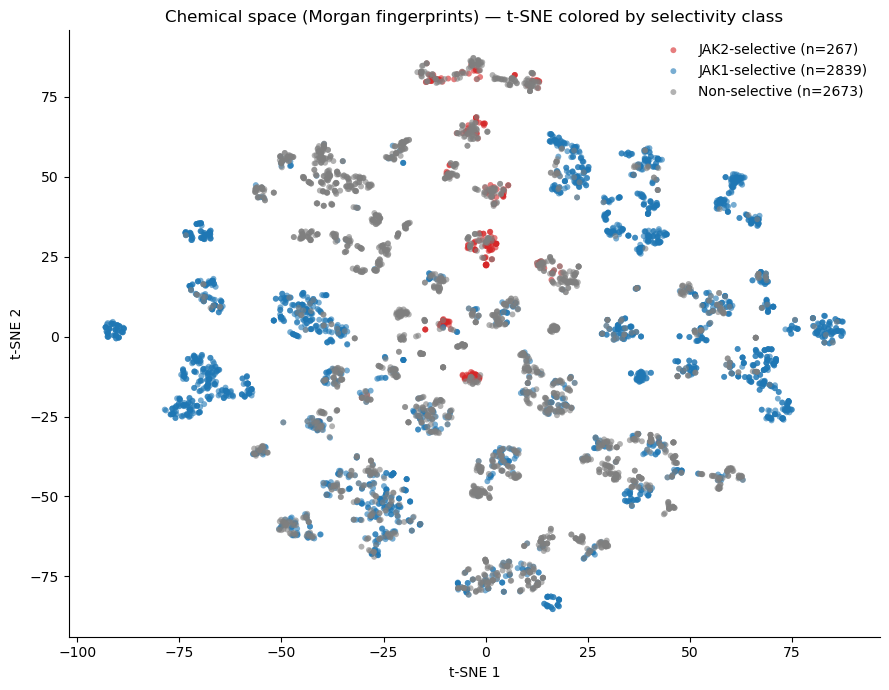


Saved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity.png


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



k-NN purity check (k=10, Jaccard/Tanimoto distance on fingerprints)

JAK1-selective (n=2839, base rate=49.1%):
  Mean fraction of k=10 nearest neighbors sharing this class: 82.4%
  Enrichment over random expectation: 1.7x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Non-selective (n=2673, base rate=46.3%):
  Mean fraction of k=10 nearest neighbors sharing this class: 74.6%
  Enrichment over random expectation: 1.6x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

JAK2-selective (n=267, base rate=4.6%):
  Mean fraction of k=10 nearest neighbors sharing this class: 59.7%
  Enrichment over random expectation: 12.9x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Saved: knn_purity_results.csv

Interpretation: enrichment > 1x with a low p-value means compounds of that class tend to be structurally closer to each other than random chance would predict -- i.e. there IS real chemical structure associated with that class, even if it's not obviousl

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



Nearest non-selective neighbor check for JAK2-selective compounds
Threshold: selective >= 10.0x, boundary zone = [5.0, 10.0)x, true cliff < 5.0x

pair_type
true activity cliff    267
Name: count, dtype: int64

Closest 10 JAK2-selective / non-selective pairs by structural similarity:
 jak2_fold_selectivity  nearest_nonselective_fold_selectivity  tanimoto_similarity           pair_type
              6.628337                               2.891008             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              7.184211                               4.805031             1.000000 true activity cliff
              5.175676                               2.625000             1.000000 true activity cliff
              5.469880                               4.309942             1.000000 true activity 

In [22]:
RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    # Keep fold_selectivity alongside smiles -- needed later to distinguish
    # "boundary artifact" overlap from genuine activity-cliff overlap.
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")
    tmp = df[cols].copy()
    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan
    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []
for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4 (common default for similarity/ML)
# fpSize=2048 -> standard bit-vector length; bump to 4096 for less bit collision
# on larger/more diverse datasets, at the cost of more memory.
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset (no discriminative value)
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. (Optional) PCA pre-reduction, then t-SNE
# ----------------------------------------------------------------------------
# Running t-SNE directly on 2000+ binary dimensions works but is slow and can
# be noisy. Standard practice is to first reduce to ~50 dims with PCA (fast,
# linear, keeps the bulk of the signal), then let t-SNE do the nonlinear work
# from there. Set PCA_PREREDUCE = False to skip straight to t-SNE on raw bits.
PCA_PREREDUCE = True
N_PCA_DIMS = 50  # only used if PCA_PREREDUCE is True

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
          f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)")

# perplexity roughly controls the balance between local and global structure;
# scikit-learn recommends keeping it well below the number of samples.
PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    n_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot TSNE1 vs TSNE2, color-coded by dataset
# ----------------------------------------------------------------------------
colors = {
    "JAK2-selective": "#d62728",  # red
    "JAK1-selective": "#1f77b4",  # blue
    "Non-selective": "#7f7f7f",   # gray
}

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in colors.items():
    subset = tsne_df[tsne_df["dataset"] == label]
    ax.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        s=18,
        alpha=0.6,
        c=color,
        label=f"{label} (n={len(subset)})",
        edgecolors="none",
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) — t-SNE colored by selectivity class")
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_tsne_selectivity.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
print("\nSaved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity.png")

# Notes:
# - t-SNE axes have no inherent meaning (unlike PCA loadings) — distances within
#   a cluster and cluster shape aren't meaningful, only relative grouping is.
#   Don't over-interpret exact distances or axis values.
# - t-SNE is stochastic and sensitive to `perplexity` and `random_state`. If the
#   plot looks like one big blob or oddly stringy, try re-running with a
#   different perplexity (roughly: smaller for tighter local clusters, larger
#   for more global structure) before concluding there's no separation.
# - If you want to know *why* clusters separate, it's more useful to pick a few
#   molecules from each cluster and visually compare their structures
#   (e.g. with Chem.Draw), since fingerprint bits aren't individually
#   interpretable the way Mordred descriptors are.

# ----------------------------------------------------------------------------
# 7. k-NN purity check — is there real structural signal despite low n / visual
#    overlap in the 2D embedding?
# ----------------------------------------------------------------------------
# Rationale: a 2D t-SNE/PCA plot compresses away a lot of information, and with
# only ~126 JAK2-selective compounds among 5,779, a real-but-subtle structural
# signal can be invisible to the eye even if it exists. This check works
# directly in fingerprint space (not the 2D embedding) and asks, for each
# compound: "of my k nearest structural neighbors, what fraction share my
# class?" then compares that to the class's overall base rate in the dataset.
# If JAK2-selective compounds are structurally random with respect to class,
# their neighbor purity should hover around the base rate (~2.2%). If there's
# real (even minority-subgroup) structure, purity will sit meaningfully above
# it, with a significance test to back that up.
from sklearn.neighbors import NearestNeighbors

K = 10  # number of nearest neighbors to check; try 5-20

# Use Jaccard/Tanimoto distance on the raw binary fingerprints — this is the
# standard similarity metric for fingerprints (better suited than Euclidean).
nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")  # +1 to exclude self
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self (always the nearest neighbor at distance 0)

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    # observed mean purity: for each compound of this class, fraction of its
    # k neighbors that are also this class
    neighbor_labels = labels[neighbor_idx[cls_idx]]  # shape (n_cls, K)
    observed_purity = (neighbor_labels == cls).mean()

    # permutation test: shuffle class labels many times and recompute the same
    # statistic, to get a null distribution and an empirical p-value
    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        # sample same number of indices as observed for comparability, using
        # the same neighbor structure (fingerprint space is fixed; only labels
        # are permuted, which is the correct null model here)
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
purity_df.to_csv("knn_purity_results.csv")
print("\nSaved: knn_purity_results.csv")
print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict -- i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE/PCA "
    "plot. Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size -- consistent with what "
    "the overlapping t-SNE clusters suggested, but now with a statistic behind it "
    "rather than a visual impression."
)

# ----------------------------------------------------------------------------
# 8. Nearest non-selective neighbor check for JAK2-selective compounds:
#    boundary-labeling artifact vs. genuine activity cliff
# ----------------------------------------------------------------------------
# Rationale: when a JAK2-selective (red) compound sits right next to a
# non-selective (gray) compound in fingerprint/t-SNE space, there are two very
# different explanations that look identical in a class-colored plot:
#   (a) BOUNDARY ARTIFACT -- the neighbor's fold_selectivity is just under your
#       cutoff (e.g. 6-9x vs. a 10x threshold). These are probably near-identical
#       compounds that landed on opposite sides of an arbitrary/noisy line, not
#       a real chemical distinction.
#   (b) TRUE ACTIVITY CLIFF -- the neighbor's fold_selectivity is clearly low
#       (e.g. <5x) despite being structurally very similar to a selective
#       compound. This is a real, chemically interesting SAR signal.
# Adjust SELECTIVE_THRESHOLD and BOUNDARY_ZONE_LOW to match how your
# selectivity_category / selective columns were actually defined.
SELECTIVE_THRESHOLD = 10.0   # fold-selectivity cutoff used to call something "selective"
BOUNDARY_ZONE_LOW = 5.0      # neighbor fold_selectivity >= this and < threshold -> boundary artifact
                              # neighbor fold_selectivity < this -> true cliff

jak2_mask = labels == "JAK2-selective"
nonsel_mask = labels == "Non-selective"

jak2_idx = np.where(jak2_mask)[0]
nonsel_idx = np.where(nonsel_mask)[0]

X_nonsel = X[nonsel_idx]

# Fit nearest-neighbor search restricted to the non-selective set only, so we
# find each JAK2-selective compound's closest non-selective match specifically
# (rather than its closest neighbor of any class, which section 7 already covers).
nn_nonsel = NearestNeighbors(n_neighbors=1, metric="jaccard")
nn_nonsel.fit(X_nonsel)
dist_to_nonsel, nn_in_nonsel = nn_nonsel.kneighbors(X[jak2_idx])

dist_to_nonsel = dist_to_nonsel.ravel()
matched_global_idx = nonsel_idx[nn_in_nonsel.ravel()]

cliff_df = pd.DataFrame({
    "jak2_smiles": tsne_df.iloc[jak2_idx]["smiles"].values,
    "jak2_fold_selectivity": tsne_df.iloc[jak2_idx]["fold_selectivity"].values,
    "nearest_nonselective_smiles": tsne_df.iloc[matched_global_idx]["smiles"].values,
    "nearest_nonselective_fold_selectivity": tsne_df.iloc[matched_global_idx]["fold_selectivity"].values,
    "tanimoto_distance": dist_to_nonsel,          # 0 = identical fingerprint, 1 = no shared bits
    "tanimoto_similarity": 1 - dist_to_nonsel,
})

def classify_pair(fold_sel):
    if pd.isna(fold_sel):
        return "unknown (missing fold_selectivity)"
    elif fold_sel < BOUNDARY_ZONE_LOW:
        return "true activity cliff"
    elif fold_sel < SELECTIVE_THRESHOLD:
        return "boundary artifact"
    else:
        return "neighbor above threshold (mislabeled or edge case -- check data)"

cliff_df["pair_type"] = cliff_df["nearest_nonselective_fold_selectivity"].apply(classify_pair)

print("\n" + "=" * 70)
print("Nearest non-selective neighbor check for JAK2-selective compounds")
print("=" * 70)
print(f"Threshold: selective >= {SELECTIVE_THRESHOLD}x, "
      f"boundary zone = [{BOUNDARY_ZONE_LOW}, {SELECTIVE_THRESHOLD})x, "
      f"true cliff < {BOUNDARY_ZONE_LOW}x\n")
print(cliff_df["pair_type"].value_counts())

# Focus on the structurally closest pairs -- these are the ones where "overlap"
# in the t-SNE plot is most likely to be literally the same red/gray dots
# sitting on top of each other, so they're the most informative to inspect.
print("\nClosest 10 JAK2-selective / non-selective pairs by structural similarity:")
closest_pairs = cliff_df.sort_values("tanimoto_distance").head(10)
print(closest_pairs[[
    "jak2_fold_selectivity", "nearest_nonselective_fold_selectivity",
    "tanimoto_similarity", "pair_type"
]].to_string(index=False))

cliff_df.to_csv("jak2_boundary_vs_cliff_check.csv", index=False)
print("\nSaved: jak2_boundary_vs_cliff_check.csv")
print(
    "\nInterpretation: if most structurally-close pairs are 'boundary artifact', "
    "the red/gray overlap you see in the t-SNE plot is largely explained by "
    "near-identical compounds landing on opposite sides of the fold-selectivity "
    "cutoff -- a labeling/threshold effect rather than a chemistry finding. If "
    "many pairs are 'true activity cliff' (structurally near-identical, but the "
    "neighbor's fold_selectivity is clearly low), that's real, interesting SAR: "
    "small structural changes are driving large selectivity swings, and those "
    "specific pairs are worth a closer look (e.g. draw both structures side by "
    "side with RDKit's Draw.MolsToGridImage)."
)

In [37]:
cliff_df = pd.read_csv("jak2_boundary_vs_cliff_check.csv")

In [51]:
cliff_df

,jak2_smiles,jak2_fold_selectivity,nearest_nonselective_smiles,nearest_nonselective_fold_selectivity,tanimoto_distance,tanimoto_similarity,pair_type
0,CC(C)(C)OC(=O)N1CC(CC#N)(n2nc(NC3CC3)c3c(=O)[n...,16.254980,CCNc1nn(C2(CC#N)CN(C(=O)OC(C)(C)C)C2)c2cc[nH]c...,7.120192,0.218750,0.781250,boundary artifact
1,CC(C)(C)S(=O)(=O)Nc1cc(-n2ccc3cnc(Nc4cc(F)c5c(...,123.141767,CN1CCC(NC(=O)c2ccc(Nc3ncc4ccn(-c5cccc(NS(=O)(=...,4.956522,0.540816,0.459184,true activity cliff
2,CC(C)(C)S(=O)(=O)Nc1cc(-n2ccc3cnc(Nc4ccc(N5CCN...,41.932991,CN1CCC(NC(=O)c2ccc(Nc3ncc4ccn(-c5cccc(NS(=O)(=...,4.956522,0.500000,0.500000,true activity cliff
3,CC(C)(C)S(=O)(=O)Nc1cccc(-c2csc3cnc(Nc4ccc(N5C...,84.500000,CN1CCC(NC(=O)c2ccc(Nc3ncc4ccn(-c5cccc(NS(=O)(=...,4.956522,0.616162,0.383838,true activity cliff
4,CC(C)(C)S(=O)(=O)Nc1cccc(-c2csc3cnc(Nc4ccc5c(c...,22.000000,CN1CCC(NC(=O)c2ccc(Nc3ncc4ccn(-c5cccc(NS(=O)(=...,4.956522,0.634615,0.365385,true activity cliff
...,...,...,...,...,...,...,...
121,O=C(Nc1ccc2cncc(CC(F)(F)F)c2c1)[C@@H]1CC1c1ccc...,33.050847,O=C(Nc1ccc2cncc(F)c2c1)[C@@H]1CC1c1ccc(S(=O)(=...,8.485311,0.217391,0.782609,boundary artifact
122,O=C(Nc1ccc2cncc(Cl)c2c1)[C@@H]1CC1c1ccc(S(=O)(...,25.448335,O=C(Nc1ccc2cncc(Cl)c2c1)[C@@H]1CC1c1ccc(S(=O)(...,2.857143,0.206349,0.793651,true activity cliff
123,O=C(Nc1ccc2cnccc2c1)[C@@H]1CC1c1ccc(S(=O)(=O)N...,22.821671,O=C(Nc1ccc2cnccc2c1)[C@@H]1CC1c1ccc(S(=O)(=O)N...,4.468085,0.209677,0.790323,true activity cliff
124,O=C(O)C(Cc1ccccc1)Oc1nc(-c2cnn3ccccc23)nc(N[C@...,13.108108,C[C@@H](CO)Oc1nc(-c2cnn3ccccc23)nc(N[C@@H]2CCC...,9.666667,0.230769,0.769231,boundary artifact


In [53]:
row = cliff_df.loc[cliff_df["tanimoto_similarity"] == 1]

jak2_smiles = row["jak2_smiles"].iloc[0]
nearest_nonselective_smiles = row["nearest_nonselective_smiles"].iloc[0]

print(jak2_smiles)
print(nearest_nonselective_smiles)

CCOC(=O)Cn1cc(Nc2ncc3ccn(C[C@H]4CC[C@@H](OC)CC4)c3n2)cn1
CCOC(=O)Cn1cc(Nc2ncc3ccn(C[C@H]4CC[C@H](OC)CC4)c3n2)cn1


In [55]:
shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",7.500000,No,None,5x
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",3.380952,No,None,2x
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.545455,No,None,5x
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.000000,No,None,2x
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.822785,No,None,5x
...,...,...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.952381,No,None,2x
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.197802,No,None,2x
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.325581,No,None,2x
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.454545,No,None,2x


In [65]:
target_smiles = "CCOC(=O)Cn1cc(Nc2ncc3ccn(C[C@H]4CC[C@H](OC)CC4)c3n2)cn1"

matches = shared_df.loc[shared_df["smiles"] == target_smiles]

In [67]:
matches

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
1085,CCOC(=O)Cn1cc(Nc2ncc3ccn(C[C@H]4CC[C@H](OC)CC4...,550.0,100.0,JAK/TYK2 Assay: 10 mM test compound stock or 1...,5.5,No,None,5x


In [29]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def count_unique_scaffolds(df, smiles_col='smiles'):
    """
    Calculate the number of unique Bemis-Murcko scaffolds in a dataframe.
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing a column of SMILES strings.
    smiles_col : str
        Name of the column containing SMILES strings.
    
    Returns
    -------
    dict with:
        'n_molecules'      : total number of molecules processed
        'n_valid'          : number of molecules that parsed successfully
        'n_unique_scaffolds': number of unique Murcko scaffolds
        'scaffold_counts'  : pd.Series of scaffold -> count, sorted descending
    """
    scaffolds = []
    n_invalid = 0

    for smi in df[smiles_col]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            n_invalid += 1
            continue
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            scaffold_smiles = Chem.MolToSmiles(scaffold, canonical=True)
        except Exception:
            n_invalid += 1
            continue
        scaffolds.append(scaffold_smiles)

    import pandas as pd
    scaffold_counts = pd.Series(scaffolds).value_counts()

    return {
        'n_molecules': len(df),
        'n_valid': len(scaffolds),
        'n_invalid': n_invalid,
        'n_unique_scaffolds': scaffold_counts.shape[0],
        'scaffold_counts': scaffold_counts,
    }

In [31]:
datasets = {
    'JAK1_selective': jak1_selective_df,
    'JAK2_selective': jak2_selective_df,
    'Non_selective': non_selective_df,
}

summary = []
for name, df in datasets.items():
    result = count_unique_scaffolds(df, smiles_col='smiles')
    summary.append({
        'dataset': name,
        'n_molecules': result['n_molecules'],
        'n_valid': result['n_valid'],
        'n_unique_scaffolds': result['n_unique_scaffolds'],
        'scaffold_diversity': round(result['n_unique_scaffolds'] / result['n_valid'], 3),
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

          dataset  n_molecules  n_valid  n_unique_scaffolds  \
0  JAK1_selective         1950     1950                 642   
1  JAK2_selective          126      126                  72   
2   Non_selective         3703     3703                1350   

   scaffold_diversity  
0               0.329  
1               0.571  
2               0.365  


Total compounds combined: 5779
  JAK2-selective: 267
  JAK1-selective: 2839
  Non-selective: 2673
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


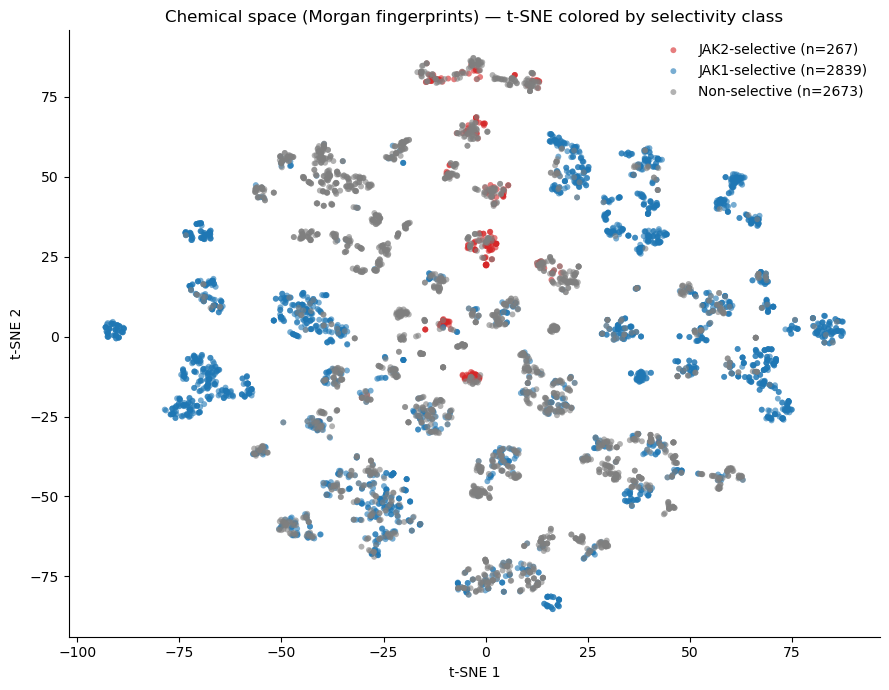

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



k-NN purity check (k=10, Jaccard/Tanimoto distance on fingerprints)

JAK1-selective (n=2839, base rate=49.1%):
  Mean fraction of k=10 nearest neighbors sharing this class: 82.4%
  Enrichment over random expectation: 1.7x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Non-selective (n=2673, base rate=46.3%):
  Mean fraction of k=10 nearest neighbors sharing this class: 74.6%
  Enrichment over random expectation: 1.6x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

JAK2-selective (n=267, base rate=4.6%):
  Mean fraction of k=10 nearest neighbors sharing this class: 59.7%
  Enrichment over random expectation: 12.9x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Interpretation: enrichment > 1x with a low p-value means compounds of that class tend to be structurally closer to each other than random chance would predict -- i.e. there IS real chemical structure associated with that class, even if it's not obviously visible as a separate cluster

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



Nearest non-selective neighbor check for JAK2-selective compounds
Threshold: selective >= 10.0x, boundary zone = [5.0, 10.0)x, true cliff < 5.0x

pair_type
true activity cliff    267
Name: count, dtype: int64

Closest 10 JAK2-selective / non-selective pairs by structural similarity:
 jak2_fold_selectivity  nearest_nonselective_fold_selectivity  tanimoto_similarity           pair_type
              6.628337                               2.891008             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              7.184211                               4.805031             1.000000 true activity cliff
              5.175676                               2.625000             1.000000 true activity cliff
              5.469880                               4.309942             1.000000 true activity 

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings


datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")
    tmp = df[cols].copy()
    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan
    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

mols = []
valid_idx = []
for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

PCA_PREREDUCE = True
N_PCA_DIMS = 50  # only used if PCA_PREREDUCE is True

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
          f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)")

PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    n_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

colors = {
    "JAK2-selective": "#d62728",  # red
    "JAK1-selective": "#1f77b4",  # blue
    "Non-selective": "#7f7f7f",   # gray
}

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in colors.items():
    subset = tsne_df[tsne_df["dataset"] == label]
    ax.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        s=18,
        alpha=0.6,
        c=color,
        label=f"{label} (n={len(subset)})",
        edgecolors="none",
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) — t-SNE colored by selectivity class")
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
## plt.savefig("morgan_tsne_selectivity.png", dpi=300)
plt.show()

# tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
# print("Saved")


from sklearn.neighbors import NearestNeighbors

K = 10  # number of nearest neighbors to check; try 5-20

nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")  # +1 to exclude self
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self (always the nearest neighbor at distance 0)

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    neighbor_labels = labels[neighbor_idx[cls_idx]]  # shape (n_cls, K)
    observed_purity = (neighbor_labels == cls).mean()

    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
# purity_df.to_csv("knn_purity_results.csv")
# print("Saved")
print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict -- i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE/PCA "
    "plot. Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size -- consistent with what "
    "the overlapping t-SNE clusters suggested, but now with a statistic behind it "
    "rather than a visual impression."
)

SELECTIVE_THRESHOLD = 10.0   # fold-selectivity cutoff used to call something "selective"
BOUNDARY_ZONE_LOW = 5.0      # neighbor fold_selectivity >= this and < threshold -> boundary artifact

jak2_mask = labels == "JAK2-selective"
nonsel_mask = labels == "Non-selective"

jak2_idx = np.where(jak2_mask)[0]
nonsel_idx = np.where(nonsel_mask)[0]

X_nonsel = X[nonsel_idx]

nn_nonsel = NearestNeighbors(n_neighbors=1, metric="jaccard")
nn_nonsel.fit(X_nonsel)
dist_to_nonsel, nn_in_nonsel = nn_nonsel.kneighbors(X[jak2_idx])

dist_to_nonsel = dist_to_nonsel.ravel()
matched_global_idx = nonsel_idx[nn_in_nonsel.ravel()]

cliff_df = pd.DataFrame({
    "jak2_smiles": tsne_df.iloc[jak2_idx]["smiles"].values,
    "jak2_fold_selectivity": tsne_df.iloc[jak2_idx]["fold_selectivity"].values,
    "nearest_nonselective_smiles": tsne_df.iloc[matched_global_idx]["smiles"].values,
    "nearest_nonselective_fold_selectivity": tsne_df.iloc[matched_global_idx]["fold_selectivity"].values,
    "tanimoto_distance": dist_to_nonsel,          # 0 = identical fingerprint, 1 = no shared bits
    "tanimoto_similarity": 1 - dist_to_nonsel,
})

def classify_pair(fold_sel):
    if pd.isna(fold_sel):
        return "unknown (missing fold_selectivity)"
    elif fold_sel < BOUNDARY_ZONE_LOW:
        return "true activity cliff"
    elif fold_sel < SELECTIVE_THRESHOLD:
        return "boundary artifact"
    else:
        return "neighbor above threshold (mislabeled or edge case -- check data)"

cliff_df["pair_type"] = cliff_df["nearest_nonselective_fold_selectivity"].apply(classify_pair)

print("\n" + "=" * 70)
print("Nearest non-selective neighbor check for JAK2-selective compounds")
print("=" * 70)
print(f"Threshold: selective >= {SELECTIVE_THRESHOLD}x, "
      f"boundary zone = [{BOUNDARY_ZONE_LOW}, {SELECTIVE_THRESHOLD})x, "
      f"true cliff < {BOUNDARY_ZONE_LOW}x\n")
print(cliff_df["pair_type"].value_counts())

print("\nClosest 10 JAK2-selective / non-selective pairs by structural similarity:")
closest_pairs = cliff_df.sort_values("tanimoto_distance").head(10)
print(closest_pairs[[
    "jak2_fold_selectivity", "nearest_nonselective_fold_selectivity",
    "tanimoto_similarity", "pair_type"
]].to_string(index=False))

# cliff_df.to_csv("jak2_boundary_vs_cliff_check.csv", index=False)
# print("Saved")
print(
    "\nInterpretation: if most structurally-close pairs are 'boundary artifact', "
    "the red/gray overlap you see in the t-SNE plot is largely explained by "
    "near-identical compounds landing on opposite sides of the fold-selectivity "
    "cutoff -- a labeling/threshold effect rather than a chemistry finding. If "
    "many pairs are 'true activity cliff' (structurally near-identical, but the "
    "neighbor's fold_selectivity is clearly low), that's real, interesting SAR: "
    "small structural changes are driving large selectivity swings, and those "
    "specific pairs are worth a closer look (e.g. draw both structures side by "
    "side with RDKit's Draw.MolsToGridImage)."
)

Total compounds combined: 5779
  JAK2-selective: 267
  JAK1-selective: 2839
  Non-selective: 2673
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


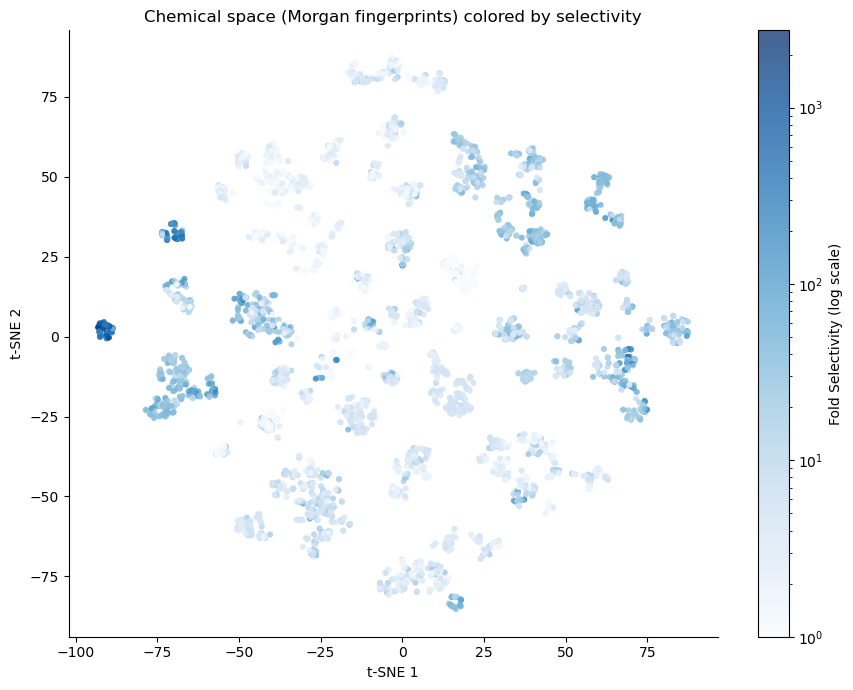


Saved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)

KeyboardInterrupt



In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from matplotlib.colors import LogNorm

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")

    tmp = df[cols].copy()

    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan

    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []

for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4
# fpSize=2048 -> standard bit-vector length
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. Optional PCA pre-reduction, then t-SNE
# ----------------------------------------------------------------------------
PCA_PREREDUCE = True
N_PCA_DIMS = 50

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(
        f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
        f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)"
    )

PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot TSNE1 vs TSNE2 with a gradient for fold selectivity
# ----------------------------------------------------------------------------
# This uses a light-to-dark blue colormap instead of hard class colors.
# A log scale usually works best because selectivity spans a wide range.
plot_df = tsne_df.dropna(subset=["fold_selectivity"]).copy()

if len(plot_df) == 0:
    raise ValueError("No compounds have fold_selectivity values to plot.")

use_log_norm = (plot_df["fold_selectivity"] > 0).all()

fig, ax = plt.subplots(figsize=(9, 7))

if use_log_norm:
    scatter = ax.scatter(
        plot_df["TSNE1"],
        plot_df["TSNE2"],
        c=plot_df["fold_selectivity"],
        cmap="Blues",
        norm=LogNorm(
            vmin=plot_df["fold_selectivity"].min(),
            vmax=plot_df["fold_selectivity"].max(),
        ),
        s=18,
        alpha=0.75,
        edgecolors="none",
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Fold Selectivity (log scale)")
else:
    # Fallback if any fold_selectivity values are zero or negative
    scatter = ax.scatter(
        plot_df["TSNE1"],
        plot_df["TSNE2"],
        c=plot_df["fold_selectivity"],
        cmap="Blues",
        s=18,
        alpha=0.75,
        edgecolors="none",
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Fold Selectivity")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) colored by selectivity")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_tsne_selectivity_gradient.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
print("\nSaved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png")

# Notes:
# - t-SNE axes have no inherent meaning — only relative neighborhood structure matters.
# - t-SNE is stochastic and sensitive to perplexity and random_state.
# - If the plot looks blob-like or stringy, try changing perplexity before drawing conclusions.
# - For interpretation, it is often helpful to inspect representative compounds from
#   light-blue vs dark-blue regions using Chem.Draw.

# ----------------------------------------------------------------------------
# 7. k-NN purity check — is there real structural signal despite overlap?
# ----------------------------------------------------------------------------
# This check works directly in fingerprint space and asks, for each compound:
# "of my k nearest structural neighbors, what fraction share my class?"
# Then it compares that to the class's overall base rate in the dataset.

K = 10  # number of nearest neighbors to check; try 5-20

# Jaccard distance on binary fingerprints approximates Tanimoto distance
nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    neighbor_labels = labels[neighbor_idx[cls_idx]]
    observed_purity = (neighbor_labels == cls).mean()

    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
purity_df.to_csv("knn_purity_results.csv")
print("\nSaved: knn_purity_results.csv")

print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict — i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE plot. "
    "Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size."
)

# ----------------------------------------------------------------------------
# 8. Nearest non-selective neighbor check for JAK2-selective compounds:
#    boundary-labeling artifact vs genuine activity cliff
# ----------------------------------------------------------------------------
SELECTIVE_THRESHOLD = 10.0
BOUNDARY_ZONE_LOW = 5.0

jak2_mask = labels == "JAK2-selective"
nonsel_mask = labels == "Non-selective"

jak2_idx = np.where(jak2_mask)[0]
nonsel_idx = np.where(nonsel_mask)[0]

X_nonsel = X[nonsel_idx]

nn_nonsel = NearestNeighbors(n_neighbors=1, metric="jaccard")
nn_nonsel.fit(X_nonsel)
dist_to_nonsel, nn_in_nonsel = nn_nonsel.kneighbors(X[jak2_idx])

dist_to_nonsel = dist_to_nonsel.ravel()
matched_global_idx = nonsel_idx[nn_in_nonsel.ravel()]

cliff_df = pd.DataFrame({
    "jak2_smiles": tsne_df.iloc[jak2_idx]["smiles"].values,
    "jak2_fold_selectivity": tsne_df.iloc[jak2_idx]["fold_selectivity"].values,
    "nearest_nonselective_smiles": tsne_df.iloc[matched_global_idx]["smiles"].values,
    "nearest_nonselective_fold_selectivity": tsne_df.iloc[matched_global_idx]["fold_selectivity"].values,
    "tanimoto_distance": dist_to_nonsel,
    "tanimoto_similarity": 1 - dist_to_nonsel,
})

def classify_pair(fold_sel):
    if pd.isna(fold_sel):
        return "unknown (missing fold_selectivity)"
    elif fold_sel < BOUNDARY_ZONE_LOW:
        return "true activity cliff"
    elif fold_sel < SELECTIVE_THRESHOLD:
        return "boundary artifact"
    else:
        return "neighbor above threshold (mislabeled or edge case -- check data)"

cliff_df["pair_type"] = cliff_df["nearest_nonselective_fold_selectivity"].apply(classify_pair)

print("\n" + "=" * 70)
print("Nearest non-selective neighbor check for JAK2-selective compounds")
print("=" * 70)
print(
    f"Threshold: selective >= {SELECTIVE_THRESHOLD}x, "
    f"boundary zone = [{BOUNDARY_ZONE_LOW}, {SELECTIVE_THRESHOLD})x, "
    f"true cliff < {BOUNDARY_ZONE_LOW}x\n"
)
print(cliff_df["pair_type"].value_counts())

print("\nClosest 10 JAK2-selective / non-selective pairs by structural similarity:")
closest_pairs = cliff_df.sort_values("tanimoto_distance").head(10)
print(closest_pairs[[
    "jak2_fold_selectivity",
    "nearest_nonselective_fold_selectivity",
    "tanimoto_similarity",
    "pair_type",
]].to_string(index=False))

cliff_df.to_csv("jak2_boundary_vs_cliff_check.csv", index=False)
print("\nSaved: jak2_boundary_vs_cliff_check.csv")

print(
    "\nInterpretation: if most structurally-close pairs are 'boundary artifact', "
    "the red/gray overlap you saw before was likely driven by threshold effects. "
    "If many pairs are 'true activity cliff', that suggests real SAR where small "
    "structural changes drive large selectivity shifts."
)

Total compounds combined: 5779
  JAK2-selective: 267
  JAK1-selective: 2839
  Non-selective: 2673
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


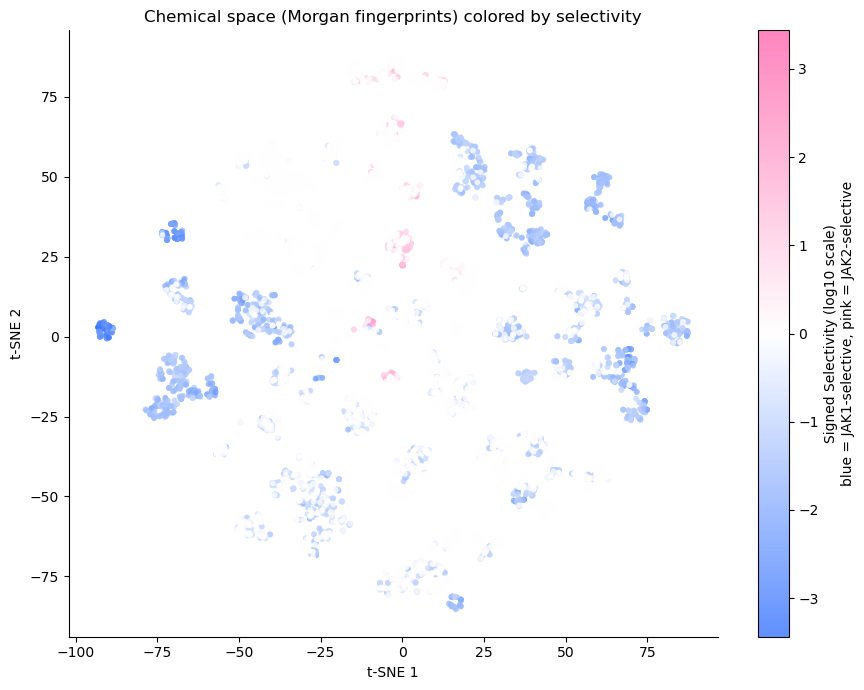


Saved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



k-NN purity check (k=10, Jaccard/Tanimoto distance on fingerprints)

JAK1-selective (n=2839, base rate=49.1%):
  Mean fraction of k=10 nearest neighbors sharing this class: 82.4%
  Enrichment over random expectation: 1.7x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Non-selective (n=2673, base rate=46.3%):
  Mean fraction of k=10 nearest neighbors sharing this class: 74.6%
  Enrichment over random expectation: 1.6x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

JAK2-selective (n=267, base rate=4.6%):
  Mean fraction of k=10 nearest neighbors sharing this class: 59.7%
  Enrichment over random expectation: 12.9x
  Permutation test p-value: 0.0000  <-- significant at p<0.05

Saved: knn_purity_results.csv

Interpretation: enrichment > 1x with a low p-value means compounds of that class tend to be structurally closer to each other than random chance would predict — i.e. there IS real chemical structure associated with that class, even if it's not obviously

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



Nearest non-selective neighbor check for JAK2-selective compounds
Threshold: selective >= 10.0x, boundary zone = [5.0, 10.0)x, true cliff < 5.0x

pair_type
true activity cliff    267
Name: count, dtype: int64

Closest 10 JAK2-selective / non-selective pairs by structural similarity:
 jak2_fold_selectivity  nearest_nonselective_fold_selectivity  tanimoto_similarity           pair_type
              6.628337                               2.891008             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              5.500000                               1.000000             1.000000 true activity cliff
              7.184211                               4.805031             1.000000 true activity cliff
              5.175676                               2.625000             1.000000 true activity cliff
              5.469880                               4.309942             1.000000 true activity 

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")

    tmp = df[cols].copy()

    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan

    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []

for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4
# fpSize=2048 -> standard bit-vector length
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. Optional PCA pre-reduction, then t-SNE
# ----------------------------------------------------------------------------
PCA_PREREDUCE = True
N_PCA_DIMS = 50

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(
        f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
        f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)"
    )

PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot TSNE1 vs TSNE2 with a pink-white-blue gradient
# ----------------------------------------------------------------------------
# Blue = strongly JAK1-selective
# White = non-selective
# Pink = strongly JAK2-selective
#
# We use a signed score:
#   + = JAK2-selective
#   - = JAK1-selective
#    0 = non-selective
#
# The magnitude is log10(fold_selectivity), so stronger selectivity gets
# more saturated color.
plot_df = tsne_df.copy()
plot_df["signed_selectivity"] = 0.0

jak2_mask = plot_df["dataset"] == "JAK2-selective"
jak1_mask = plot_df["dataset"] == "JAK1-selective"
non_mask = plot_df["dataset"] == "Non-selective"

# Convert selectivity magnitude to a log scale so extreme values don't dominate.
# If fold_selectivity is missing for some selective compounds, those rows are dropped.
selective_mask = jak2_mask | jak1_mask
sel_mag = pd.to_numeric(plot_df.loc[selective_mask, "fold_selectivity"], errors="coerce")

# Keep only positive values for the log transform
sel_mag = sel_mag.where(sel_mag > 0)

# Assign signed log scores
plot_df.loc[jak2_mask, "signed_selectivity"] = np.log10(sel_mag.loc[jak2_mask].clip(lower=1.0))
plot_df.loc[jak1_mask, "signed_selectivity"] = -np.log10(sel_mag.loc[jak1_mask].clip(lower=1.0))
plot_df.loc[non_mask, "signed_selectivity"] = 0.0

# Drop rows where we still do not have a valid score
missing_score = plot_df["signed_selectivity"].isna().sum()
if missing_score > 0:
    print(f"[warn] Dropping {missing_score} rows with missing/invalid selectivity values for plotting.")
    plot_df = plot_df.dropna(subset=["signed_selectivity"]).copy()

# Build a symmetric diverging scale centered at 0
max_abs = np.nanmax(np.abs(plot_df["signed_selectivity"].values))
if max_abs == 0 or np.isnan(max_abs):
    max_abs = 1.0

norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

pink_blue = LinearSegmentedColormap.from_list(
    "pink_blue",
    ["#2b6cff", "#ffffff", "#ff5ca8"],  # blue -> white -> pink
)

fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    plot_df["TSNE1"],
    plot_df["TSNE2"],
    c=plot_df["signed_selectivity"],
    cmap=pink_blue,
    norm=norm,
    s=18,
    alpha=0.75,
    edgecolors="none",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Signed Selectivity (log10 scale)\nblue = JAK1-selective, pink = JAK2-selective")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) colored by selectivity")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_tsne_selectivity_gradient.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
print("\nSaved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png")

# Notes:
# - t-SNE axes have no inherent meaning — only relative neighborhood structure matters.
# - t-SNE is stochastic and sensitive to perplexity and random_state.
# - If the plot looks blob-like or stringy, try changing perplexity before drawing conclusions.
# - For interpretation, it is often helpful to inspect representative compounds from
#   deep blue vs white vs deep pink regions using Chem.Draw.

# ----------------------------------------------------------------------------
# 7. k-NN purity check — is there real structural signal despite overlap?
# ----------------------------------------------------------------------------
# This check works directly in fingerprint space and asks, for each compound:
# "of my k nearest structural neighbors, what fraction share my class?"
# Then it compares that to the class's overall base rate in the dataset.

K = 10  # number of nearest neighbors to check; try 5-20

# Jaccard distance on binary fingerprints approximates Tanimoto distance
nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    neighbor_labels = labels[neighbor_idx[cls_idx]]
    observed_purity = (neighbor_labels == cls).mean()

    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
purity_df.to_csv("knn_purity_results.csv")
print("\nSaved: knn_purity_results.csv")

print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict — i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE plot. "
    "Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size."
)

# ----------------------------------------------------------------------------
# 8. Nearest non-selective neighbor check for JAK2-selective compounds:
#    boundary-labeling artifact vs genuine activity cliff
# ----------------------------------------------------------------------------
SELECTIVE_THRESHOLD = 10.0
BOUNDARY_ZONE_LOW = 5.0

jak2_mask = labels == "JAK2-selective"
nonsel_mask = labels == "Non-selective"

jak2_idx = np.where(jak2_mask)[0]
nonsel_idx = np.where(nonsel_mask)[0]

X_nonsel = X[nonsel_idx]

nn_nonsel = NearestNeighbors(n_neighbors=1, metric="jaccard")
nn_nonsel.fit(X_nonsel)
dist_to_nonsel, nn_in_nonsel = nn_nonsel.kneighbors(X[jak2_idx])

dist_to_nonsel = dist_to_nonsel.ravel()
matched_global_idx = nonsel_idx[nn_in_nonsel.ravel()]

cliff_df = pd.DataFrame({
    "jak2_smiles": tsne_df.iloc[jak2_idx]["smiles"].values,
    "jak2_fold_selectivity": tsne_df.iloc[jak2_idx]["fold_selectivity"].values,
    "nearest_nonselective_smiles": tsne_df.iloc[matched_global_idx]["smiles"].values,
    "nearest_nonselective_fold_selectivity": tsne_df.iloc[matched_global_idx]["fold_selectivity"].values,
    "tanimoto_distance": dist_to_nonsel,
    "tanimoto_similarity": 1 - dist_to_nonsel,
})

def classify_pair(fold_sel):
    if pd.isna(fold_sel):
        return "unknown (missing fold_selectivity)"
    elif fold_sel < BOUNDARY_ZONE_LOW:
        return "true activity cliff"
    elif fold_sel < SELECTIVE_THRESHOLD:
        return "boundary artifact"
    else:
        return "neighbor above threshold (mislabeled or edge case -- check data)"

cliff_df["pair_type"] = cliff_df["nearest_nonselective_fold_selectivity"].apply(classify_pair)

print("\n" + "=" * 70)
print("Nearest non-selective neighbor check for JAK2-selective compounds")
print("=" * 70)
print(
    f"Threshold: selective >= {SELECTIVE_THRESHOLD}x, "
    f"boundary zone = [{BOUNDARY_ZONE_LOW}, {SELECTIVE_THRESHOLD})x, "
    f"true cliff < {BOUNDARY_ZONE_LOW}x\n"
)
print(cliff_df["pair_type"].value_counts())

print("\nClosest 10 JAK2-selective / non-selective pairs by structural similarity:")
closest_pairs = cliff_df.sort_values("tanimoto_distance").head(10)
print(closest_pairs[[
    "jak2_fold_selectivity",
    "nearest_nonselective_fold_selectivity",
    "tanimoto_similarity",
    "pair_type",
]].to_string(index=False))

cliff_df.to_csv("jak2_boundary_vs_cliff_check.csv", index=False)
print("\nSaved: jak2_boundary_vs_cliff_check.csv")

print(
    "\nInterpretation: if most structurally-close pairs are 'boundary artifact', "
    "the overlap in the t-SNE plot is largely explained by threshold effects. "
    "If many pairs are 'true activity cliff', that suggests real SAR where small "
    "structural changes drive large selectivity shifts."
)

Total compounds combined: 5779
  JAK2-selective: 267
  JAK1-selective: 2839
  Non-selective: 2673
Valid molecules after parsing: 5779
Calculating Morgan fingerprints (radius=2, 2048 bits)...
Fingerprint matrix shape: (5779, 2048)
Fingerprint matrix shape after dropping constant bits: (5779, 2035)
PCA pre-reduction: 2035 -> 50 dims (69.4% variance retained)
Running t-SNE (perplexity=30) on 5779 compounds...


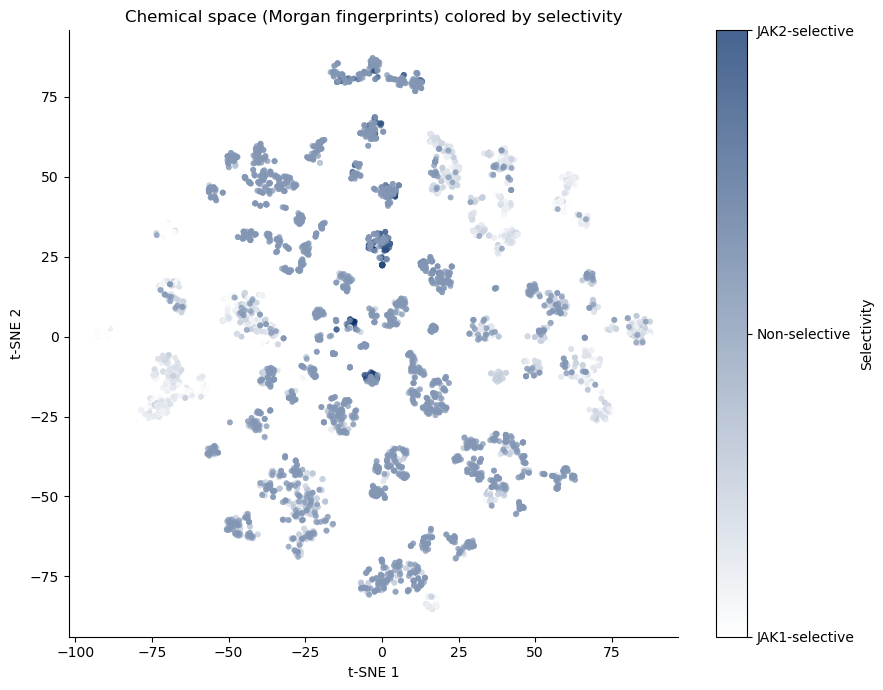


Saved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


KeyboardInterrupt: 

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from matplotlib.colors import LinearSegmentedColormap, Normalize

RDLogger.DisableLog("rdApp.*")  # silence RDKit parsing warnings

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
# If these DataFrames are already defined in your session (as in the screenshot),
# this block just labels and combines them. Otherwise, uncomment and point to
# your files, e.g.:
#
# jak2_selective_df = pd.read_csv("jak2_selective_df.csv")
# jak1_selective_df = pd.read_csv("jak1_selective_df.csv")
# non_selective_df  = pd.read_csv("non_selective_df.csv")

datasets = {
    "JAK2-selective": jak2_selective_df,
    "JAK1-selective": jak1_selective_df,
    "Non-selective": non_selective_df,
}

combined_frames = []
for label, df in datasets.items():
    cols = ["smiles"]
    if "fold_selectivity" in df.columns:
        cols.append("fold_selectivity")

    tmp = df[cols].copy()

    if "fold_selectivity" not in tmp.columns:
        tmp["fold_selectivity"] = np.nan

    tmp["dataset"] = label
    combined_frames.append(tmp)

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"Total compounds combined: {len(combined_df)}")
for label in datasets:
    print(f"  {label}: {(combined_df['dataset'] == label).sum()}")

# ----------------------------------------------------------------------------
# 2. SMILES -> RDKit Mol, dropping anything that fails to parse
# ----------------------------------------------------------------------------
mols = []
valid_idx = []

for i, smi in enumerate(combined_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
    else:
        print(f"  [warn] could not parse SMILES at row {i}: {smi}")

combined_df = combined_df.iloc[valid_idx].reset_index(drop=True)
print(f"Valid molecules after parsing: {len(mols)}")

# ----------------------------------------------------------------------------
# 3. Calculate Morgan fingerprints (ECFP-style)
# ----------------------------------------------------------------------------
# radius=2 -> roughly equivalent to ECFP4
# fpSize=2048 -> standard bit-vector length
RADIUS = 2
N_BITS = 2048

fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)

print(f"Calculating Morgan fingerprints (radius={RADIUS}, {N_BITS} bits)...")
fps = [fp_gen.GetFingerprintAsNumPy(mol) for mol in mols]
X = np.array(fps, dtype=np.uint8)

print(f"Fingerprint matrix shape: {X.shape}")

# Drop bits that are all-zero or all-one across the dataset
col_sums = X.sum(axis=0)
keep_mask = (col_sums > 0) & (col_sums < X.shape[0])
X = X[:, keep_mask]
print(f"Fingerprint matrix shape after dropping constant bits: {X.shape}")

# ----------------------------------------------------------------------------
# 4. Optional PCA pre-reduction, then t-SNE
# ----------------------------------------------------------------------------
PCA_PREREDUCE = True
N_PCA_DIMS = 50

X_input = X.astype(float)

if PCA_PREREDUCE:
    n_dims = min(N_PCA_DIMS, X_input.shape[0] - 1, X_input.shape[1])
    pre_pca = PCA(n_components=n_dims, random_state=42)
    X_input = pre_pca.fit_transform(X_input)
    print(
        f"PCA pre-reduction: {X.shape[1]} -> {n_dims} dims "
        f"({pre_pca.explained_variance_ratio_.sum():.1%} variance retained)"
    )

PERPLEXITY = min(30, max(5, (len(X_input) - 1) // 3))

print(f"Running t-SNE (perplexity={PERPLEXITY}) on {len(X_input)} compounds...")
tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    init="pca",
    learning_rate="auto",
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_input)

tsne_df = combined_df.copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

# ----------------------------------------------------------------------------
# 5. Plot TSNE1 vs TSNE2 with a white-to-blue gradient
# ----------------------------------------------------------------------------
# White = strongly JAK1-selective
# Dark blue = strongly JAK2-selective
# Non-selective compounds are placed near the middle of the scale.
#
# We build a score in [0, 1]:
#   0.0 -> strongest JAK1-selective
#   0.5 -> non-selective
#   1.0 -> strongest JAK2-selective
#
# For the selective classes, the magnitude is based on log10(fold_selectivity)
# so stronger selectivity pushes the point closer to the appropriate end.

plot_df = tsne_df.copy()

# Start with neutral midpoint for everyone
plot_df["selectivity_score"] = 0.5

# Convert fold_selectivity to numeric when possible
fold_sel = pd.to_numeric(plot_df["fold_selectivity"], errors="coerce")

# Use a robust scale for selectivity strength
# This prevents a few extreme points from flattening everything else.
valid_positive = fold_sel > 0
if valid_positive.any():
    log_sel = np.log10(fold_sel[valid_positive])
    scale_ref = np.nanpercentile(log_sel, 95)
    if not np.isfinite(scale_ref) or scale_ref <= 0:
        scale_ref = float(np.nanmax(log_sel))
    if not np.isfinite(scale_ref) or scale_ref <= 0:
        scale_ref = 1.0
else:
    scale_ref = 1.0

# Strength in [0, 1]
strength = pd.Series(np.nan, index=plot_df.index, dtype=float)
strength.loc[valid_positive] = np.clip(np.log10(fold_sel[valid_positive]) / scale_ref, 0, 1)

# Assign scores by class
jak1_mask = plot_df["dataset"] == "JAK1-selective"
jak2_mask = plot_df["dataset"] == "JAK2-selective"
non_mask = plot_df["dataset"] == "Non-selective"

# If fold_selectivity is missing for a selective compound, keep it near the midpoint
# rather than inventing a strong value.
plot_df.loc[jak1_mask, "selectivity_score"] = 0.5 - 0.5 * strength.loc[jak1_mask].fillna(0.0)
plot_df.loc[jak2_mask, "selectivity_score"] = 0.5 + 0.5 * strength.loc[jak2_mask].fillna(0.0)
plot_df.loc[non_mask, "selectivity_score"] = 0.5

# Clamp to [0, 1]
plot_df["selectivity_score"] = plot_df["selectivity_score"].clip(0, 1)

white_blue = LinearSegmentedColormap.from_list(
    "white_blue",
    ["#ffffff", "#08306b"],  # white -> dark blue
)

fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    plot_df["TSNE1"],
    plot_df["TSNE2"],
    c=plot_df["selectivity_score"],
    cmap=white_blue,
    norm=Normalize(vmin=0.0, vmax=1.0),
    s=18,
    alpha=0.75,
    edgecolors="none",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Selectivity")
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(["JAK1-selective", "Non-selective", "JAK2-selective"])

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Chemical space (Morgan fingerprints) colored by selectivity")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("morgan_tsne_selectivity_gradient.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------------
# 6. Save results
# ----------------------------------------------------------------------------
tsne_df.to_csv("tsne_results_selectivity_morgan.csv", index=False)
print("\nSaved: tsne_results_selectivity_morgan.csv, morgan_tsne_selectivity_gradient.png")

# Notes:
# - t-SNE axes have no inherent meaning — only relative neighborhood structure matters.
# - t-SNE is stochastic and sensitive to perplexity and random_state.
# - If the plot looks blob-like or stringy, try changing perplexity before drawing conclusions.
# - For interpretation, it is often helpful to inspect representative compounds from
#   the white end vs the blue end using Chem.Draw.

# ----------------------------------------------------------------------------
# 7. k-NN purity check — is there real structural signal despite overlap?
# ----------------------------------------------------------------------------
# This check works directly in fingerprint space and asks, for each compound:
# "of my k nearest structural neighbors, what fraction share my class?"
# Then it compares that to the class's overall base rate in the dataset.

K = 10  # number of nearest neighbors to check; try 5-20

# Jaccard distance on binary fingerprints approximates Tanimoto distance
nn = NearestNeighbors(n_neighbors=K + 1, metric="jaccard")
nn.fit(X)
_, neighbor_idx = nn.kneighbors(X)
neighbor_idx = neighbor_idx[:, 1:]  # drop self

labels = tsne_df["dataset"].values
class_counts = tsne_df["dataset"].value_counts()
n_total = len(tsne_df)

print("\n" + "=" * 70)
print(f"k-NN purity check (k={K}, Jaccard/Tanimoto distance on fingerprints)")
print("=" * 70)

rng = np.random.default_rng(42)
N_PERMUTATIONS = 1000

purity_results = {}
for cls in class_counts.index:
    base_rate = class_counts[cls] / n_total
    cls_mask = labels == cls
    cls_idx = np.where(cls_mask)[0]

    neighbor_labels = labels[neighbor_idx[cls_idx]]
    observed_purity = (neighbor_labels == cls).mean()

    perm_purities = np.empty(N_PERMUTATIONS)
    for p in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        shuffled_cls_idx = np.where(shuffled == cls)[0]
        perm_neighbor_labels = shuffled[neighbor_idx[shuffled_cls_idx]]
        perm_purities[p] = (perm_neighbor_labels == cls).mean()

    p_value = (perm_purities >= observed_purity).mean()
    enrichment = observed_purity / base_rate if base_rate > 0 else np.nan

    purity_results[cls] = {
        "base_rate": base_rate,
        "observed_purity": observed_purity,
        "enrichment_over_baseline": enrichment,
        "p_value": p_value,
    }

    print(f"\n{cls} (n={class_counts[cls]}, base rate={base_rate:.1%}):")
    print(f"  Mean fraction of k={K} nearest neighbors sharing this class: {observed_purity:.1%}")
    print(f"  Enrichment over random expectation: {enrichment:.1f}x")
    print(f"  Permutation test p-value: {p_value:.4f}"
          f"{'  <-- significant at p<0.05' if p_value < 0.05 else ''}")

purity_df = pd.DataFrame(purity_results).T
purity_df.to_csv("knn_purity_results.csv")
print("\nSaved: knn_purity_results.csv")

print(
    "\nInterpretation: enrichment > 1x with a low p-value means compounds of that "
    "class tend to be structurally closer to each other than random chance would "
    "predict — i.e. there IS real chemical structure associated with that class, "
    "even if it's not obviously visible as a separate cluster in the 2D t-SNE plot. "
    "Enrichment near 1x with a high p-value means the class looks structurally "
    "indistinguishable from a random draw of the same size."
)